In [7]:
# ==========================================
# 1. Imports and Device Configuration
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn for preprocessing and imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch for Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU: CUDA")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using GPU: Apple MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: Apple MPS


In [8]:
# ==========================================
# 2. Data Loading and Imputation
# ==========================================
file_path = "data/data_clean/cleaned_data_toronto_downtown.csv"
df = pd.read_csv(file_path)

df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Select numerical features
features = [
    'PM_ppb', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 
    'Precip. Amount (mm)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 
    'Visibility (km)', 'Stn Press (kPa)'
]
df_numeric = df[features].copy()

# Initialize MICE Imputer
imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df_numeric), columns=features)

# Clip physical constraints
non_negative_cols = ['PM_ppb', 'Rel Hum (%)', 'Precip. Amount (mm)', 'Wind Spd (km/h)', 'Visibility (km)']
for col in non_negative_cols:
    df_imputed[col] = df_imputed[col].clip(lower=0)

print("Data shape after imputation:", df_imputed.shape)

/var/folders/1g/lbgr3cfd3wx0g2ptlm58cz680000gn/T/ipykernel_69995/4158565594.py:5: DtypeWarning: Columns (14,16,18,20,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Data shape after imputation: (35064, 9)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [9]:
# ==========================================
# 3. Scaling and Time-Series Formatting
# ==========================================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_imputed)

TARGET_INDEX = 0 
SEQ_LENGTH = 24 
HORIZONS = [4, 6, 12, 24] 

def create_multi_horizon_sequences(data, seq_length, target_idx, horizons):
    xs, ys = [], []
    max_horizon = max(horizons)
    
    for i in range(len(data) - seq_length - max_horizon + 1):
        x = data[i:(i + seq_length)] 
        y = [data[i + seq_length + h - 1, target_idx] for h in horizons]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_multi_horizon_sequences(scaled_data, SEQ_LENGTH, TARGET_INDEX, HORIZONS)

# Train/Val/Test Split (70%, 15%, 15%)
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)

In [10]:
# ==========================================
# 4. Define LSTM and Transformer Models
# ==========================================

# Model 1: Long Short-Term Memory (LSTM)
class AirQualityLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        super(AirQualityLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :] # Take last time step
        out = self.relu(self.fc1(out))
        return self.fc2(out)


# Model 2: Time-Series Transformer
class AirQualityTransformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, output_dim, seq_length, dropout=0.2):
        super(AirQualityTransformer, self).__init__()
        
        # Project input features to d_model dimensions
        self.input_linear = nn.Linear(input_dim, d_model)
        
        # Learned positional embedding so the model understands time sequence
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_length, d_model))
        
        # Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                    dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        
        # Flatten and output
        self.fc1 = nn.Linear(d_model * seq_length, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, output_dim)
        
    def forward(self, x):
        x = self.input_linear(x)
        x = x + self.pos_encoder # Add positional context
        
        out = self.transformer_encoder(x)
        out = out.reshape(out.size(0), -1) # Flatten sequence
        
        out = self.relu(self.fc1(out))
        return self.fc2(out)

INPUT_DIM = len(features)
OUTPUT_DIM = len(HORIZONS)

In [11]:
# ==========================================
# 5. Training Function and Execution
# ==========================================
def train_model(model, model_name, epochs=20, lr=0.001):
    print(f"\n--- Training {model_name} ---")
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_history, val_history = [], []
    
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
            
        avg_train = np.mean(batch_losses)
        train_history.append(avg_train)
        
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t)
            val_loss = criterion(val_preds, y_val_t).item()
            val_history.append(val_loss)
            
        if (epoch+1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train MSE: {avg_train:.4f} | Val MSE: {val_loss:.4f}")
            
    return train_history, val_history

# Initialize Models
lstm_model = AirQualityLSTM(INPUT_DIM, hidden_dim=64, num_layers=2, output_dim=OUTPUT_DIM).to(device)
transformer_model = AirQualityTransformer(INPUT_DIM, d_model=32, nhead=4, num_layers=2, 
                                          output_dim=OUTPUT_DIM, seq_length=SEQ_LENGTH).to(device)

# Print the full architecture of the Transformer
print(transformer_model)

# Optional: Print the total number of trainable parameters (great for presentations)
total_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# Train Models
lstm_train_loss, lstm_val_loss = train_model(lstm_model, "LSTM", epochs=20)
tf_train_loss, tf_val_loss = train_model(transformer_model, "Transformer", epochs=20)

AirQualityTransformer(
  (input_linear): Linear(in_features=9, out_features=32, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc1): Linear(in_features=768, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)
Total trainable parameters: 325,572

--- Training LSTM --


--- RMSE Comparison (ppb) ---
Horizon		LSTM		Transformer
4h ahead	8.40		8.28
6h ahead	8.86		9.02
12h ahead	9.62		9.44
24h ahead	10.56		9.97


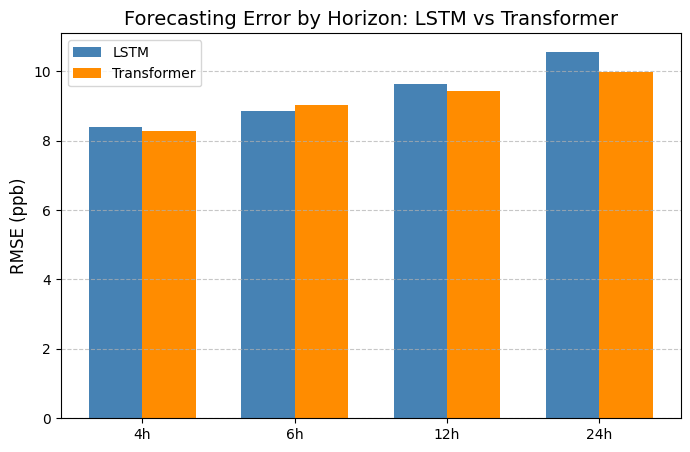

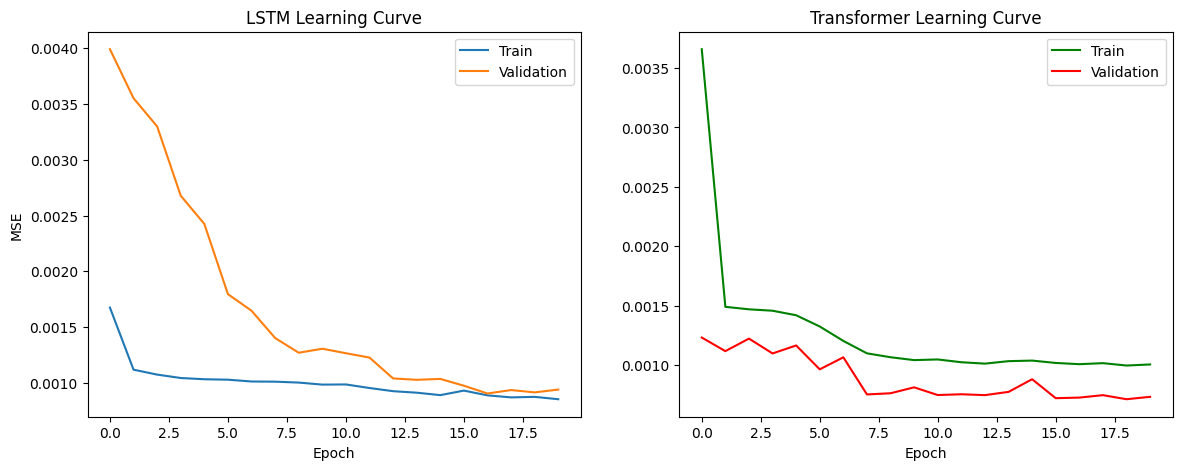

In [12]:
# ==========================================
# 6. Evaluation and Comparison
# ==========================================
def evaluate_model(model):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_t).cpu().numpy()
    
    actuals = np.zeros_like(y_test)
    preds = np.zeros_like(preds_scaled)
    
    # Inverse transform
    for i in range(len(HORIZONS)):
        dummy_a = np.zeros((len(y_test), len(features)))
        dummy_a[:, TARGET_INDEX] = y_test[:, i]
        actuals[:, i] = scaler.inverse_transform(dummy_a)[:, TARGET_INDEX]
        
        dummy_p = np.zeros((len(preds_scaled), len(features)))
        dummy_p[:, TARGET_INDEX] = preds_scaled[:, i]
        preds[:, i] = scaler.inverse_transform(dummy_p)[:, TARGET_INDEX]
        
    return actuals, preds

# Get predictions
actuals, lstm_preds = evaluate_model(lstm_model)
_, tf_preds = evaluate_model(transformer_model)

# Calculate RMSE for each horizon
lstm_rmse = [np.sqrt(mean_squared_error(actuals[:, i], lstm_preds[:, i])) for i in range(len(HORIZONS))]
tf_rmse = [np.sqrt(mean_squared_error(actuals[:, i], tf_preds[:, i])) for i in range(len(HORIZONS))]

# Print Results
print("\n--- RMSE Comparison (ppb) ---")
print(f"Horizon\t\tLSTM\t\tTransformer")
for i, h in enumerate(HORIZONS):
    print(f"{h}h ahead\t{lstm_rmse[i]:.2f}\t\t{tf_rmse[i]:.2f}")

# Plot RMSE Comparison Bar Chart
x = np.arange(len(HORIZONS))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, lstm_rmse, width, label='LSTM', color='steelblue')
ax.bar(x + width/2, tf_rmse, width, label='Transformer', color='darkorange')

ax.set_ylabel('RMSE (ppb)', fontsize=12)
ax.set_title('Forecasting Error by Horizon: LSTM vs Transformer', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f"{h}h" for h in HORIZONS])
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot Learning Curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(lstm_train_loss, label='Train')
ax1.plot(lstm_val_loss, label='Validation')
ax1.set_title('LSTM Learning Curve')
ax1.set_ylabel('MSE')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(tf_train_loss, label='Train', color='green')
ax2.plot(tf_val_loss, label='Validation', color='red')
ax2.set_title('Transformer Learning Curve')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

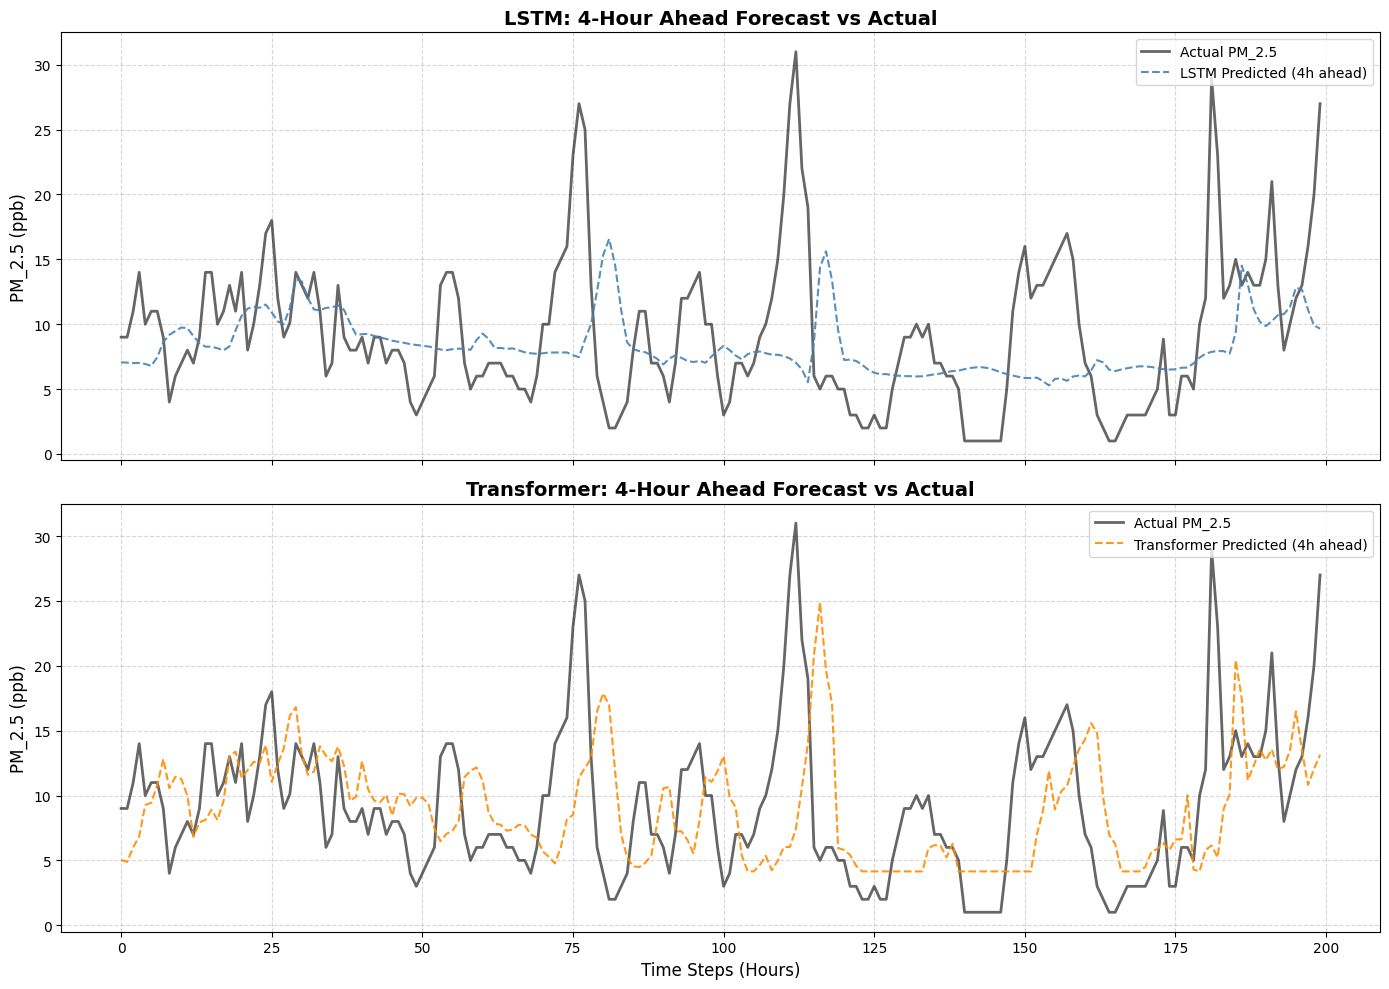

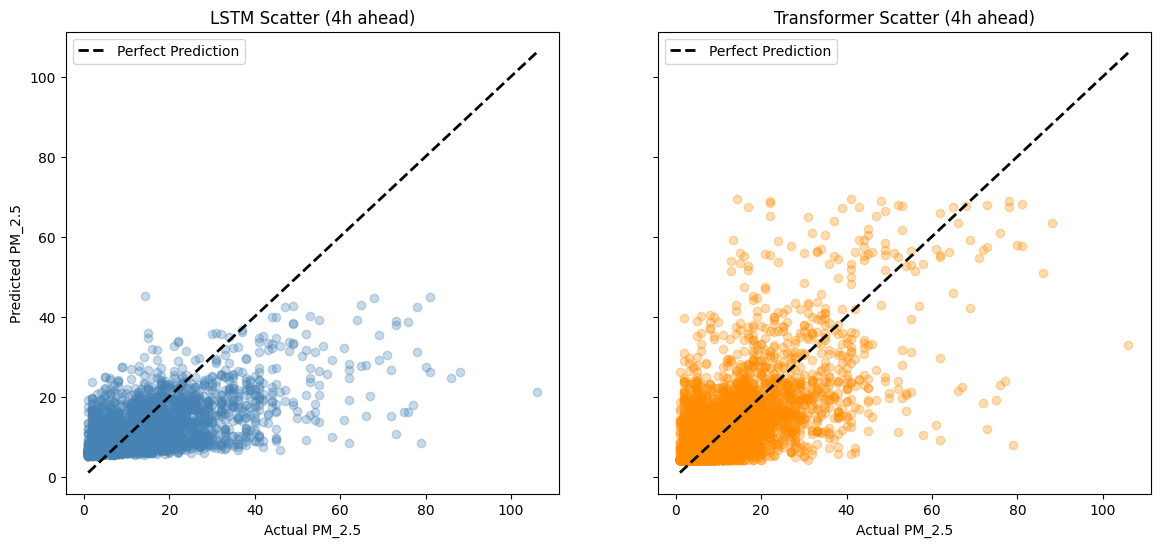

In [13]:
# ==========================================
# 7. Actual vs Predicted Time-Series Visualization
# ==========================================
# Choose a specific horizon to visualize (e.g., 24 hours ahead)
VISUALIZATION_HORIZON = 4
h_idx = HORIZONS.index(VISUALIZATION_HORIZON)

# Number of test hours to plot (zooming in on ~8 days for clarity)
plot_subset = 200 

# Create a 2-row subplot, sharing the X and Y axes for easy comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

# ------------------------------------------
# Top Panel: LSTM
# ------------------------------------------
ax1.plot(actuals[:plot_subset, h_idx], label='Actual PM_2.5', color='black', alpha=0.6, linewidth=2)
ax1.plot(lstm_preds[:plot_subset, h_idx], label=f'LSTM Predicted ({VISUALIZATION_HORIZON}h ahead)', color='steelblue', alpha=0.9, linestyle='--')
ax1.set_title(f'LSTM: {VISUALIZATION_HORIZON}-Hour Ahead Forecast vs Actual', fontsize=14, fontweight='bold')
ax1.set_ylabel('PM_2.5 (ppb)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# ------------------------------------------
# Bottom Panel: Transformer
# ------------------------------------------
ax2.plot(actuals[:plot_subset, h_idx], label='Actual PM_2.5', color='black', alpha=0.6, linewidth=2)
ax2.plot(tf_preds[:plot_subset, h_idx], label=f'Transformer Predicted ({VISUALIZATION_HORIZON}h ahead)', color='darkorange', alpha=0.9, linestyle='--')
ax2.set_title(f'Transformer: {VISUALIZATION_HORIZON}-Hour Ahead Forecast vs Actual', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time Steps (Hours)', fontsize=12)
ax2.set_ylabel('PM_2.5 (ppb)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

# Optional: Scatter plot to show correlation / distribution of errors
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Perfect prediction line boundaries
p_min = min(actuals[:, h_idx].min(), lstm_preds[:, h_idx].min(), tf_preds[:, h_idx].min())
p_max = max(actuals[:, h_idx].max(), lstm_preds[:, h_idx].max(), tf_preds[:, h_idx].max())

ax3.scatter(actuals[:, h_idx], lstm_preds[:, h_idx], alpha=0.3, color='steelblue')
ax3.plot([p_min, p_max], [p_min, p_max], 'k--', lw=2, label='Perfect Prediction')
ax3.set_title(f'LSTM Scatter ({VISUALIZATION_HORIZON}h ahead)')
ax3.set_xlabel('Actual PM_2.5')
ax3.set_ylabel('Predicted PM_2.5')
ax3.legend()

ax4.scatter(actuals[:, h_idx], tf_preds[:, h_idx], alpha=0.3, color='darkorange')
ax4.plot([p_min, p_max], [p_min, p_max], 'k--', lw=2, label='Perfect Prediction')
ax4.set_title(f'Transformer Scatter ({VISUALIZATION_HORIZON}h ahead)')
ax4.set_xlabel('Actual PM_2.5')
ax4.legend()

plt.show()

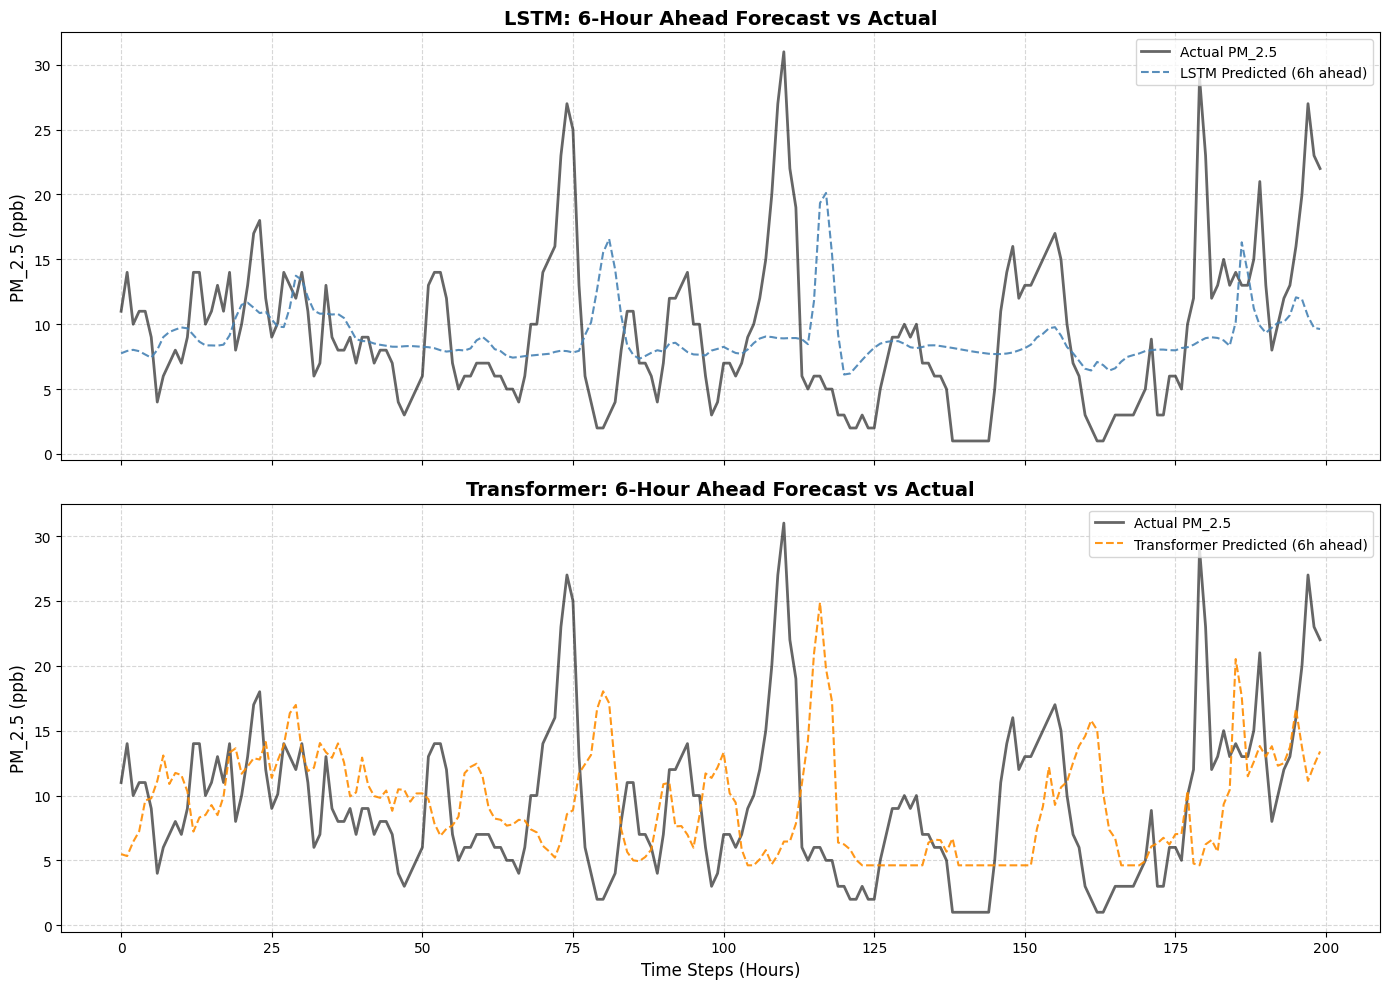

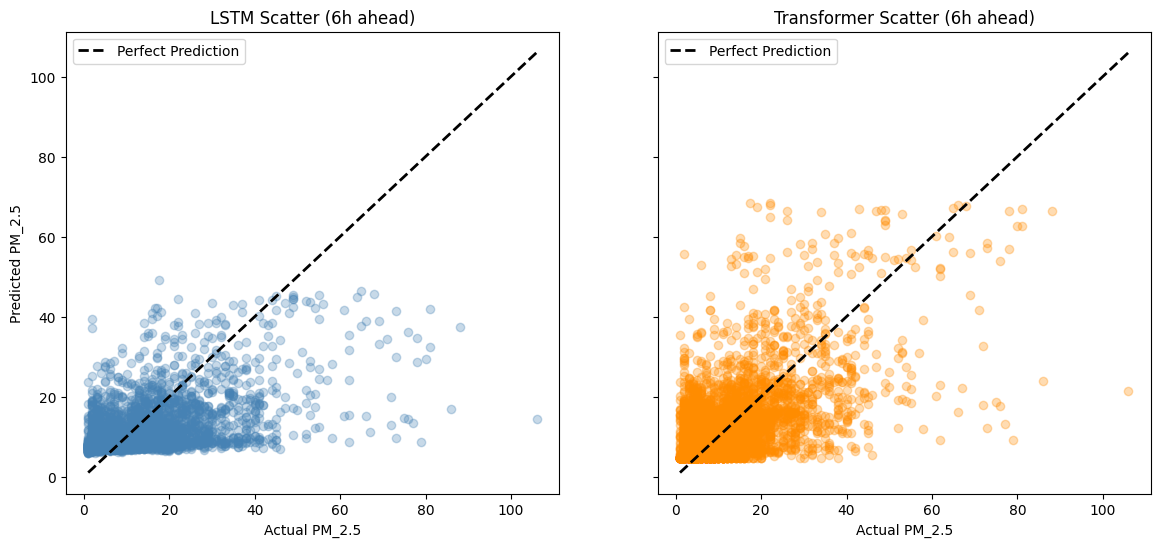

In [14]:
# ==========================================
# 7. Actual vs Predicted Time-Series Visualization
# ==========================================
# Choose a specific horizon to visualize (e.g., 24 hours ahead)
VISUALIZATION_HORIZON = 6
h_idx = HORIZONS.index(VISUALIZATION_HORIZON)

# Number of test hours to plot (zooming in on ~8 days for clarity)
plot_subset = 200 

# Create a 2-row subplot, sharing the X and Y axes for easy comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

# ------------------------------------------
# Top Panel: LSTM
# ------------------------------------------
ax1.plot(actuals[:plot_subset, h_idx], label='Actual PM_2.5', color='black', alpha=0.6, linewidth=2)
ax1.plot(lstm_preds[:plot_subset, h_idx], label=f'LSTM Predicted ({VISUALIZATION_HORIZON}h ahead)', color='steelblue', alpha=0.9, linestyle='--')
ax1.set_title(f'LSTM: {VISUALIZATION_HORIZON}-Hour Ahead Forecast vs Actual', fontsize=14, fontweight='bold')
ax1.set_ylabel('PM_2.5 (ppb)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# ------------------------------------------
# Bottom Panel: Transformer
# ------------------------------------------
ax2.plot(actuals[:plot_subset, h_idx], label='Actual PM_2.5', color='black', alpha=0.6, linewidth=2)
ax2.plot(tf_preds[:plot_subset, h_idx], label=f'Transformer Predicted ({VISUALIZATION_HORIZON}h ahead)', color='darkorange', alpha=0.9, linestyle='--')
ax2.set_title(f'Transformer: {VISUALIZATION_HORIZON}-Hour Ahead Forecast vs Actual', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time Steps (Hours)', fontsize=12)
ax2.set_ylabel('PM_2.5 (ppb)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

# Optional: Scatter plot to show correlation / distribution of errors
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Perfect prediction line boundaries
p_min = min(actuals[:, h_idx].min(), lstm_preds[:, h_idx].min(), tf_preds[:, h_idx].min())
p_max = max(actuals[:, h_idx].max(), lstm_preds[:, h_idx].max(), tf_preds[:, h_idx].max())

ax3.scatter(actuals[:, h_idx], lstm_preds[:, h_idx], alpha=0.3, color='steelblue')
ax3.plot([p_min, p_max], [p_min, p_max], 'k--', lw=2, label='Perfect Prediction')
ax3.set_title(f'LSTM Scatter ({VISUALIZATION_HORIZON}h ahead)')
ax3.set_xlabel('Actual PM_2.5')
ax3.set_ylabel('Predicted PM_2.5')
ax3.legend()

ax4.scatter(actuals[:, h_idx], tf_preds[:, h_idx], alpha=0.3, color='darkorange')
ax4.plot([p_min, p_max], [p_min, p_max], 'k--', lw=2, label='Perfect Prediction')
ax4.set_title(f'Transformer Scatter ({VISUALIZATION_HORIZON}h ahead)')
ax4.set_xlabel('Actual PM_2.5')
ax4.legend()

plt.show()

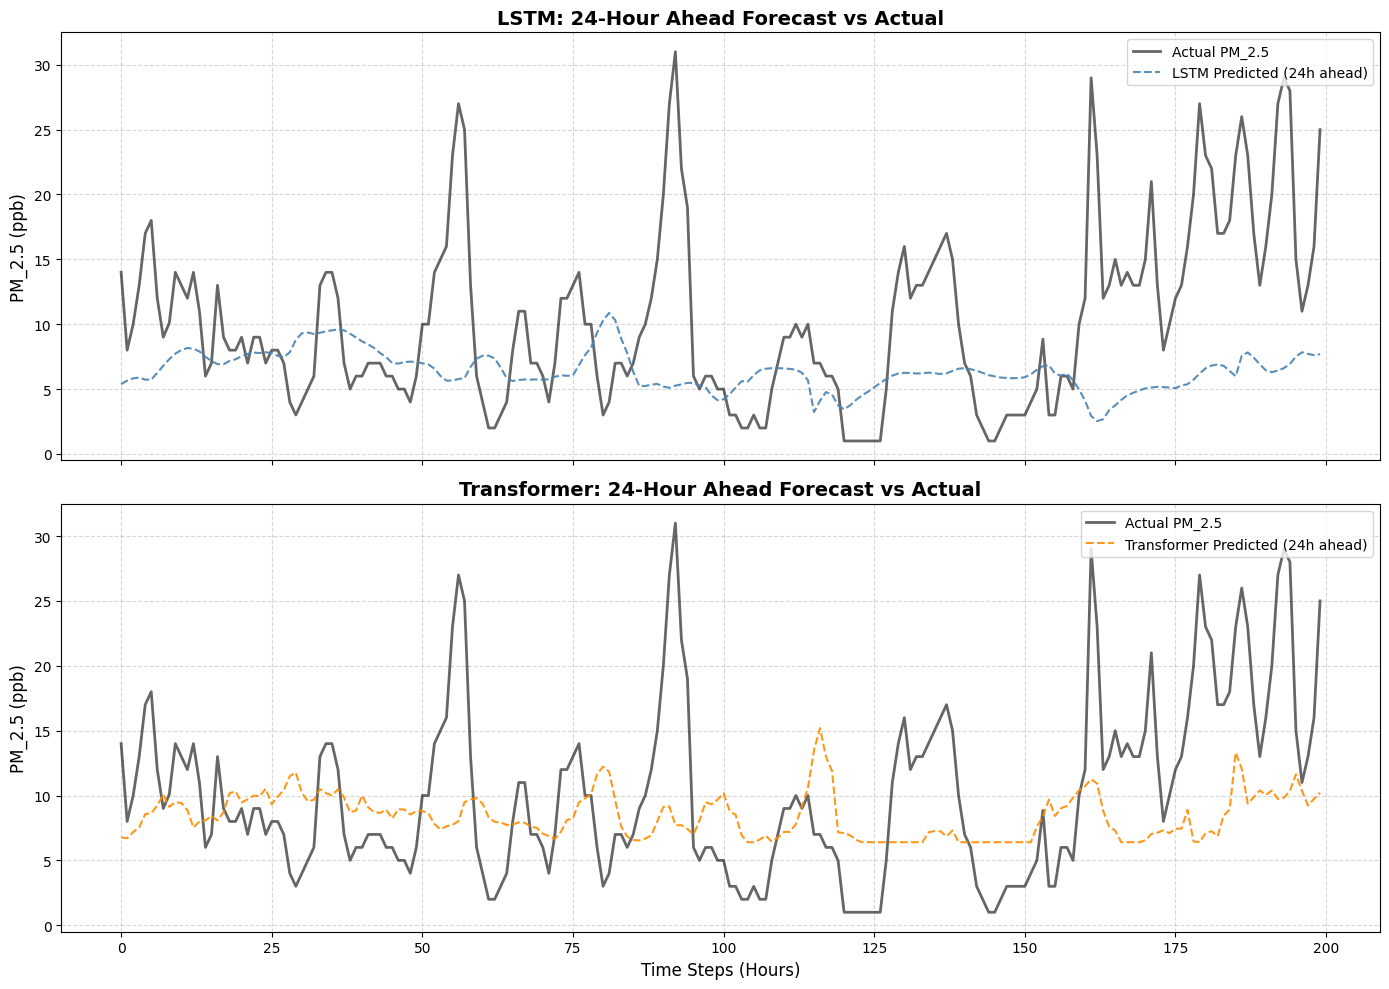

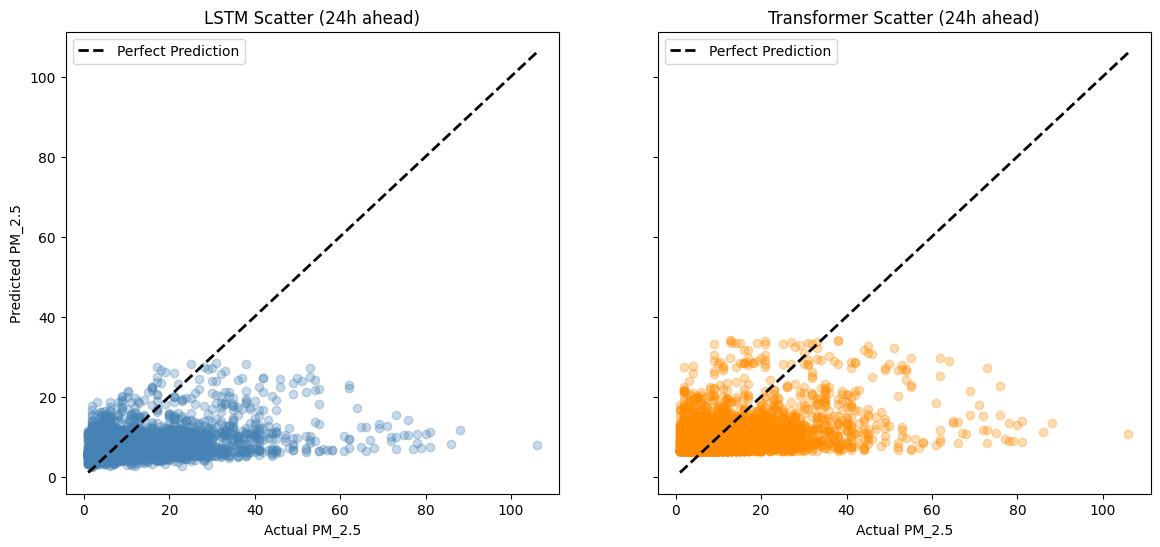

In [15]:
# ==========================================
# 7. Actual vs Predicted Time-Series Visualization
# ==========================================
# Choose a specific horizon to visualize (e.g., 24 hours ahead)
VISUALIZATION_HORIZON = 24
h_idx = HORIZONS.index(VISUALIZATION_HORIZON)

# Number of test hours to plot (zooming in on ~8 days for clarity)
plot_subset = 200 

# Create a 2-row subplot, sharing the X and Y axes for easy comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

# ------------------------------------------
# Top Panel: LSTM
# ------------------------------------------
ax1.plot(actuals[:plot_subset, h_idx], label='Actual PM_2.5', color='black', alpha=0.6, linewidth=2)
ax1.plot(lstm_preds[:plot_subset, h_idx], label=f'LSTM Predicted ({VISUALIZATION_HORIZON}h ahead)', color='steelblue', alpha=0.9, linestyle='--')
ax1.set_title(f'LSTM: {VISUALIZATION_HORIZON}-Hour Ahead Forecast vs Actual', fontsize=14, fontweight='bold')
ax1.set_ylabel('PM_2.5 (ppb)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# ------------------------------------------
# Bottom Panel: Transformer
# ------------------------------------------
ax2.plot(actuals[:plot_subset, h_idx], label='Actual PM_2.5', color='black', alpha=0.6, linewidth=2)
ax2.plot(tf_preds[:plot_subset, h_idx], label=f'Transformer Predicted ({VISUALIZATION_HORIZON}h ahead)', color='darkorange', alpha=0.9, linestyle='--')
ax2.set_title(f'Transformer: {VISUALIZATION_HORIZON}-Hour Ahead Forecast vs Actual', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time Steps (Hours)', fontsize=12)
ax2.set_ylabel('PM_2.5 (ppb)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

# Optional: Scatter plot to show correlation / distribution of errors
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Perfect prediction line boundaries
p_min = min(actuals[:, h_idx].min(), lstm_preds[:, h_idx].min(), tf_preds[:, h_idx].min())
p_max = max(actuals[:, h_idx].max(), lstm_preds[:, h_idx].max(), tf_preds[:, h_idx].max())

ax3.scatter(actuals[:, h_idx], lstm_preds[:, h_idx], alpha=0.3, color='steelblue')
ax3.plot([p_min, p_max], [p_min, p_max], 'k--', lw=2, label='Perfect Prediction')
ax3.set_title(f'LSTM Scatter ({VISUALIZATION_HORIZON}h ahead)')
ax3.set_xlabel('Actual PM_2.5')
ax3.set_ylabel('Predicted PM_2.5')
ax3.legend()

ax4.scatter(actuals[:, h_idx], tf_preds[:, h_idx], alpha=0.3, color='darkorange')
ax4.plot([p_min, p_max], [p_min, p_max], 'k--', lw=2, label='Perfect Prediction')
ax4.set_title(f'Transformer Scatter ({VISUALIZATION_HORIZON}h ahead)')
ax4.set_xlabel('Actual PM_2.5')
ax4.legend()

plt.show()